In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv


In [2]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")
df.shape

(284807, 31)

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [5]:
#df.isnull().sum()
df.isnull().values.any()

np.False_

In [6]:
df.duplicated().sum()

np.int64(1081)

In [7]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [8]:
#since the given dataset has a few columns that need to be scale
#we will be using scaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.996823,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244200,0
1,-1.996823,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342584,0
2,-1.996802,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.158900,0
3,-1.996802,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.139886,0
4,-1.996781,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073813,0


In [9]:
#now we start spliting the data
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis = 1)
y = df['Class']

#we will be using a 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

print("X_test shape:", [X_test.shape])
print("y_test shape:", [y_test.shape])

y_train.value_counts()

X_test shape: [(56746, 30)]
y_test shape: [(56746,)]


Class
0    226602
1       378
Name: count, dtype: int64

In [10]:
#now we will balance the data set
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state = 42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

y_train_smote.value_counts()

Class
0    226602
1    226602
Name: count, dtype: int64

In [11]:
# now we have a clean and a balanced dataset
# now we will use different models and measure which
#performs the best and based on that and other factors like
#if the model is good for tabular dataset or not etc., based on
#all these we will decid eon the model


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

lr = LogisticRegression(
    solver = 'liblinear',
    max_iter = 100,
    n_jobs = -1
)

rf = RandomForestClassifier(
    n_estimators = 50,
    random_state = 42,
    n_jobs = -1
)

gb = GradientBoostingClassifier()

knn = KNeighborsClassifier(
    n_neighbors = 5
)

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "KNN": knn,
    "XGBoost": xgb,
    "LightGBM": lgbm
}

for name, model in models.items():
    print("Training:", name)
    model.fit(X_train_smote, y_train_smote)


Training: Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(


Training: Random Forest
Training: Gradient Boosting
Training: KNN
Training: XGBoost
Training: LightGBM
[LightGBM] [Info] Number of positive: 226602, number of negative: 226602
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.083603 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 453204, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000



Model: Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746


Model: Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.75      0.82        95

    accuracy                           1.00     56746
   macro avg       0.95      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746


Model: Gradient Boosting
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56651
           1       0.11      0.84      0.20        95

    accuracy                           0.99     56746
   macro avg       0.56      0.92      0.60     5674

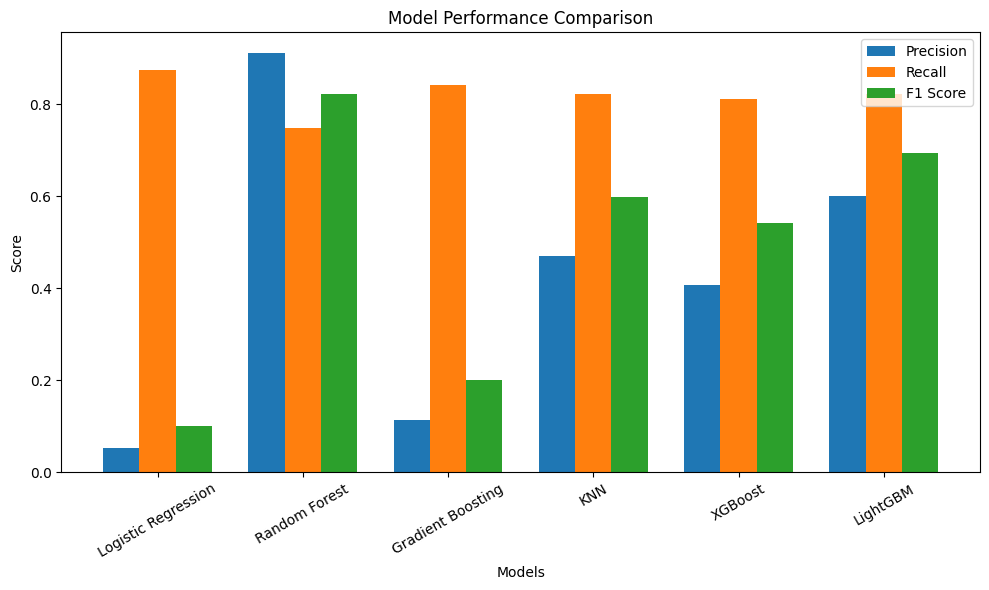

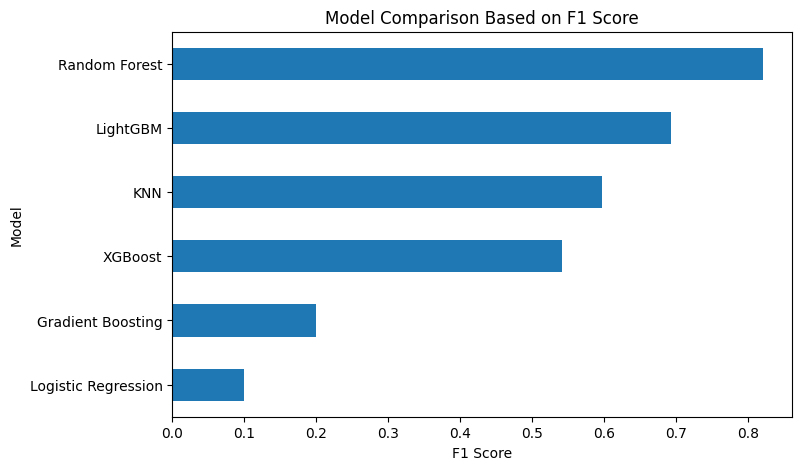

In [12]:
predictions = {}

for name, model in models.items():
    
    pred = model.predict(X_test)
    
    predictions[name] = pred

from sklearn.metrics import classification_report
for name, pred in predictions.items():
    
    print("\nModel:", name)
    
    print(classification_report(y_test, pred))

from sklearn.metrics import roc_auc_score
for name, model in models.items():
    
    probs = model.predict_proba(X_test)[:,1]
    
    auc = roc_auc_score(y_test, probs)
    
    print(name, "ROC-AUC:\n", auc)


from sklearn.metrics import precision_score, recall_score, f1_score

results = []

for name, model in models.items():
    
    pred = model.predict(X_test)
    
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    
    results.append([name, precision, recall, f1])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Precision", "Recall", "F1 Score"]
)

results_df

import matplotlib.pyplot as plt
import numpy as np

models_list = results_df["Model"]

x = np.arange(len(models_list))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, results_df["Precision"], width, label="Precision")
plt.bar(x, results_df["Recall"], width, label="Recall")
plt.bar(x + width, results_df["F1 Score"], width, label="F1 Score")

plt.xticks(x, models_list, rotation=30)

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Model Performance Comparison")

plt.legend()

plt.tight_layout()
plt.show()

results_df.sort_values("F1 Score").plot(
    x="Model",
    y="F1 Score",
    kind="barh",
    figsize=(8,5),
    legend=False,
    title="Model Comparison Based on F1 Score"
)

plt.xlabel("F1 Score")
plt.show()

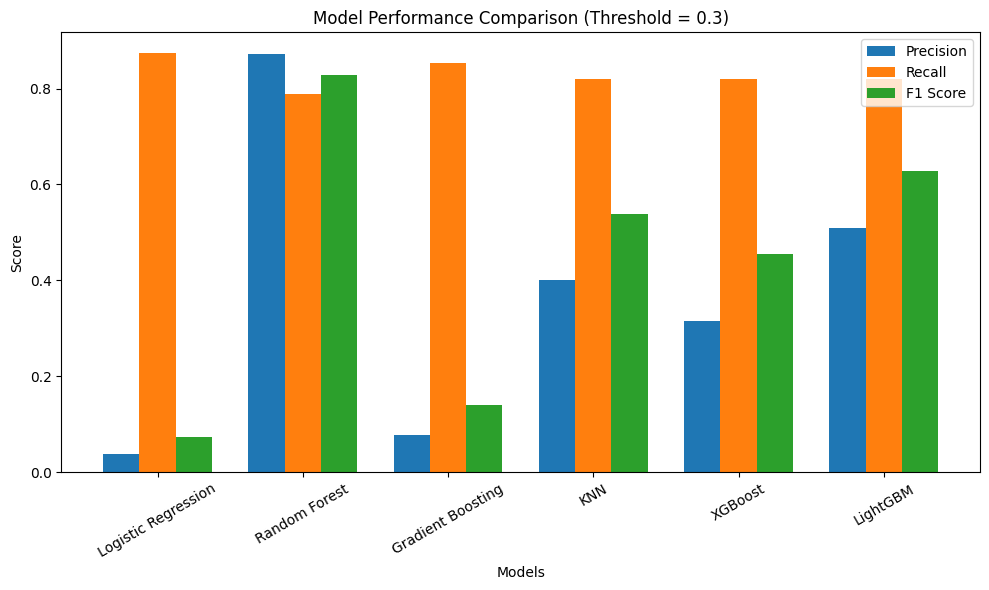

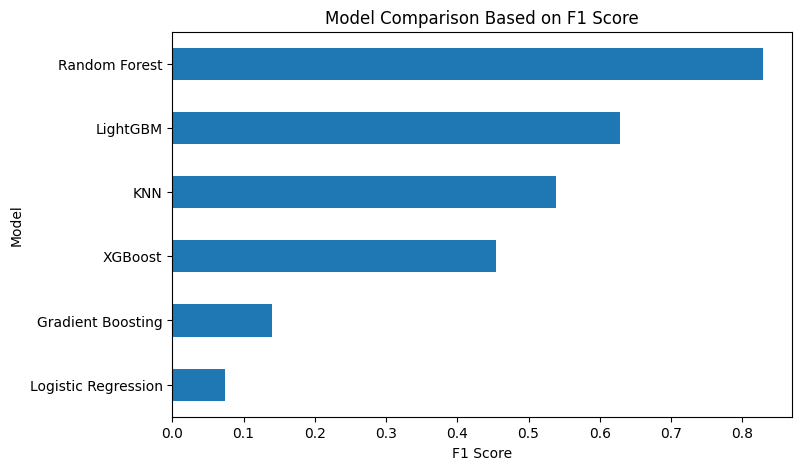

In [13]:
#above we tried to predict directly instead of predicting
#probabilities

pred_probs = {}

for name, model in models.items():
    
    probs = model.predict_proba(X_test)[:,1]
    
    pred_probs[name] = probs
#this theshold was 0.3 intially(randomly selected)
#this was changed to 0.4 later after testing, which you
#will see later
threshold = 0.4

predictions = {}

for name, probs in pred_probs.items():
    
    preds = (probs >= threshold).astype(int)
    
    predictions[name] = preds


results = []

for name, preds in predictions.items():
    
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    results.append([name, precision, recall, f1])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Precision", "Recall", "F1 Score"]
)

results_df



models_list = results_df["Model"]

x = np.arange(len(models_list))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, results_df["Precision"], width, label="Precision")
plt.bar(x, results_df["Recall"], width, label="Recall")
plt.bar(x + width, results_df["F1 Score"], width, label="F1 Score")

plt.xticks(x, models_list, rotation=30)

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Model Performance Comparison (Threshold = 0.3)")

plt.legend()

plt.tight_layout()
plt.show()

results_df.sort_values("F1 Score").plot(
    x="Model",
    y="F1 Score",
    kind="barh",
    figsize=(8,5),
    legend=False,
    title="Model Comparison Based on F1 Score"
)

plt.xlabel("F1 Score")
plt.show()

Best Threshold: 0.40000000000000013
Best F1 Score: 0.8426966292134831


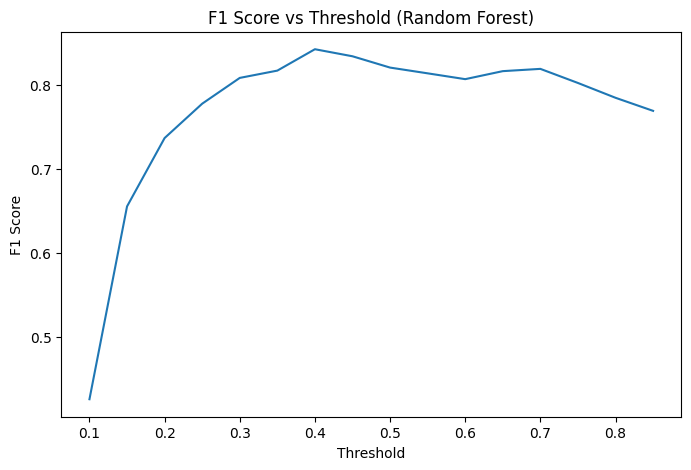

In [14]:
import numpy as np
from sklearn.metrics import f1_score

rf_probs = models["Random Forest"].predict_proba(X_test)[:,1]

thresholds = np.arange(0.1, 0.9, 0.05)

best_threshold = 0
best_f1 = 0

for t in thresholds:
    
    preds = (rf_probs >= t).astype(int)
    
    score = f1_score(y_test, preds)
    
    if score > best_f1:
        best_f1 = score
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best F1 Score:", best_f1)

scores = []

for t in thresholds:
    
    preds = (rf_probs >= t).astype(int)
    
    scores.append(f1_score(y_test, preds))

plt.figure(figsize=(8,5))

plt.plot(thresholds, scores)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold (Random Forest)")

plt.show()

[LightGBM] [Info] Number of positive: 226602, number of negative: 226602
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.089282 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 453204, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Normal        56612
Fraud            80
Suspicious       54
Name: count, dtype: int64


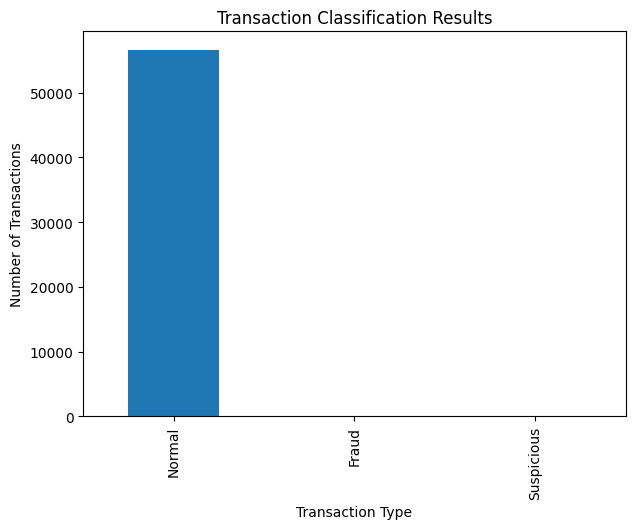

In [15]:
#from all the above models, Random Forest,XGBoost
#LightGBM are selected because
#tree-based means fast inference
#and prallelizable
#and scalable

from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('lgbm', lgbm)
    ],
    voting='soft'
)

voting_model.fit(X_train_smote, y_train_smote)

voting_probs = voting_model.predict_proba(X_test)[:,1]

def classify_transaction(prob):
    
    if prob >= 0.7:
        return "Fraud"
    
    elif prob >= 0.4:
        return "Suspicious"
    
    else:
        return "Normal"

three_class_predictions = [classify_transaction(p) for p in voting_probs]



prediction_counts = pd.Series(three_class_predictions).value_counts()

print(prediction_counts)


prediction_counts.plot(
    kind='bar', 
    figsize=(7,5),
    title="Transaction Classification Results"
)

plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.show()

Best Threshold (Voting): 0.7500000000000002
Best F1 Score (Voting): 0.8372093023255814


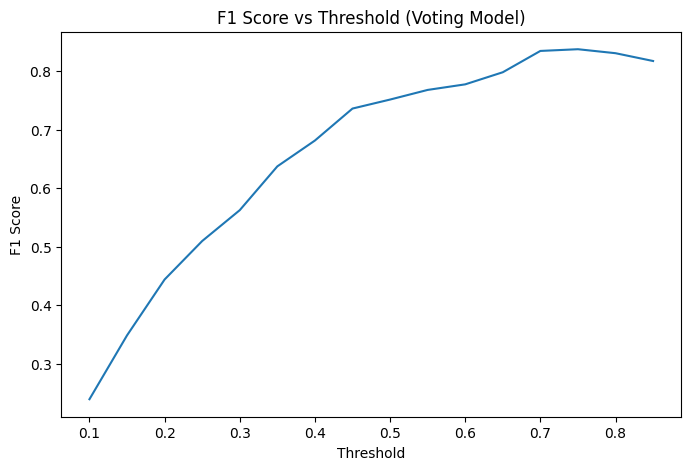

In [16]:
#we ran to check for best threshold only on random
#forest, we need to do it on the voting classifier

voting_probs = voting_model.predict_proba(X_test)[:,1]


thresholds = np.arange(0.1, 0.9, 0.05)

best_threshold_voting = 0
best_f1_voting = 0

for t in thresholds:
    
    preds = (voting_probs >= t).astype(int)
    
    score = f1_score(y_test, preds)
    
    if score > best_f1_voting:
        best_f1_voting = score
        best_threshold_voting = t

print("Best Threshold (Voting):", best_threshold_voting)
print("Best F1 Score (Voting):", best_f1_voting)

scores = []

for t in thresholds:
    
    preds = (voting_probs >= t).astype(int)
    
    scores.append(f1_score(y_test, preds))

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(thresholds, scores)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold (Voting Model)")

plt.show()

Using Final Threshold: 0.7500000000000002
Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.94      0.76      0.84        95

    accuracy                           1.00     56746
   macro avg       0.97      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:

[[56646     5]
 [   23    72]]
Final Voting Model ROC-AUC: 0.9824454253141813


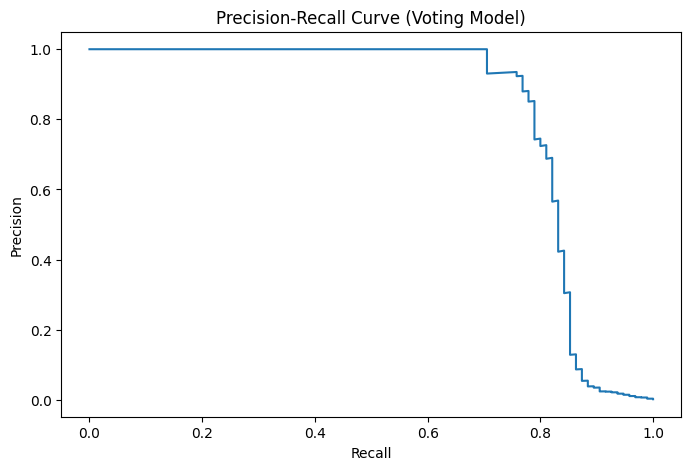

In [17]:
voting_probs = voting_model.predict_proba(X_test)[:,1]

threshold = best_threshold_voting
print("Using Final Threshold:", threshold)

final_preds = (voting_probs >= threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:\n")
print(classification_report(y_test, final_preds))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, final_preds))

from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, voting_probs)
print("Final Voting Model ROC-AUC:", auc)

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, voting_probs)

plt.figure(figsize=(8,5))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Voting Model)")

plt.show()

Normal        56607
Fraud            77
Suspicious       62
Name: count, dtype: int64


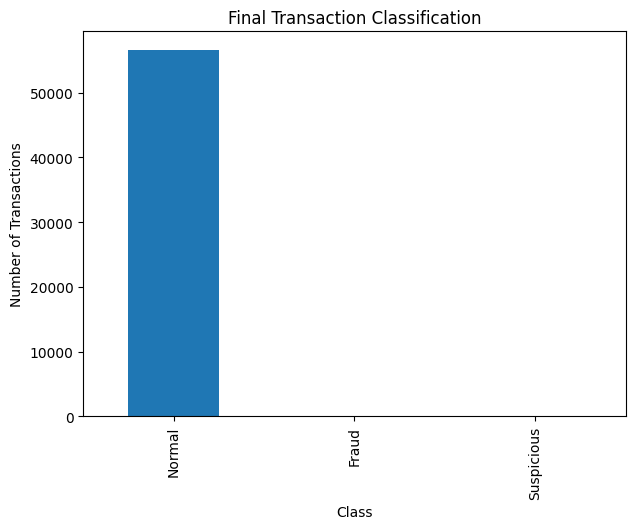

,Probability,Predicted Class
0,0.000350,Normal
1,0.000426,Normal
2,0.004126,Normal
3,0.000515,Normal
4,0.009384,Normal
5,0.002213,Normal
6,0.000776,Normal
7,0.000040,Normal
8,0.002640,Normal
9,0.000503,Normal


In [18]:
def classify_transaction(prob):
    
    if prob >= threshold:
        return "Fraud"
    
    elif prob >= (threshold / 2):
        return "Suspicious"
    
    else:
        return "Normal"


three_class_preds = [classify_transaction(p) for p in voting_probs]

import pandas as pd

class_counts = pd.Series(three_class_preds).value_counts()

print(class_counts)

class_counts.plot(
    kind='bar',
    figsize=(7,5),
    title="Final Transaction Classification"
)

plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

results_df_final = pd.DataFrame({
    "Probability": voting_probs,
    "Predicted Class": three_class_preds
})

results_df_final.head(10)